# 🧠 BCI + LLMs: Usando EEG para gerar linguagem com apoio de IA

Do pensamento ao texto: como IA pode ajudar a decodificar sinais cerebrais



# ▶️ Instalar dependências


In [1]:
!pip install torch numpy pandas scikit-learn chromadb matplotlib seaborn

# 📥 Baixar o dataset EEGIS

In [2]:
# 📥 Baixar o dataset EEGIS
!wget -O eegis.zip https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/73g4fw884c-1.zip
!unzip -q eegis.zip

--2025-10-03 13:54:21--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/73g4fw884c-1.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 52.218.25.128, 3.5.70.177, 3.5.70.136, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|52.218.25.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 377525903 (360M) [application/zip]
Saving to: ‘eegis.zip’

eegis.zip           100%[===================>] 360.04M  32.7MB/s    in 12s     

2025-10-03 13:54:34 (29.8 MB/s) - ‘eegis.zip’ saved [377525903/377525903]



## Exibir algumas amostras de atividades cerebrais

✅ DataFrame com amostras de cada classe:
   classe_id classe_nome  arquivo  \
0          0          Sí  386.csv   
1          1          No  386.csv   
2          2        Baño  256.csv   
3          3      Hambre  386.csv   
4          4         Sed  386.csv   
5          5       Ayuda  386.csv   
6          6       Dolor  386.csv   
7          7     Gracias  386.csv   
8          8      Reposo  386.csv   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

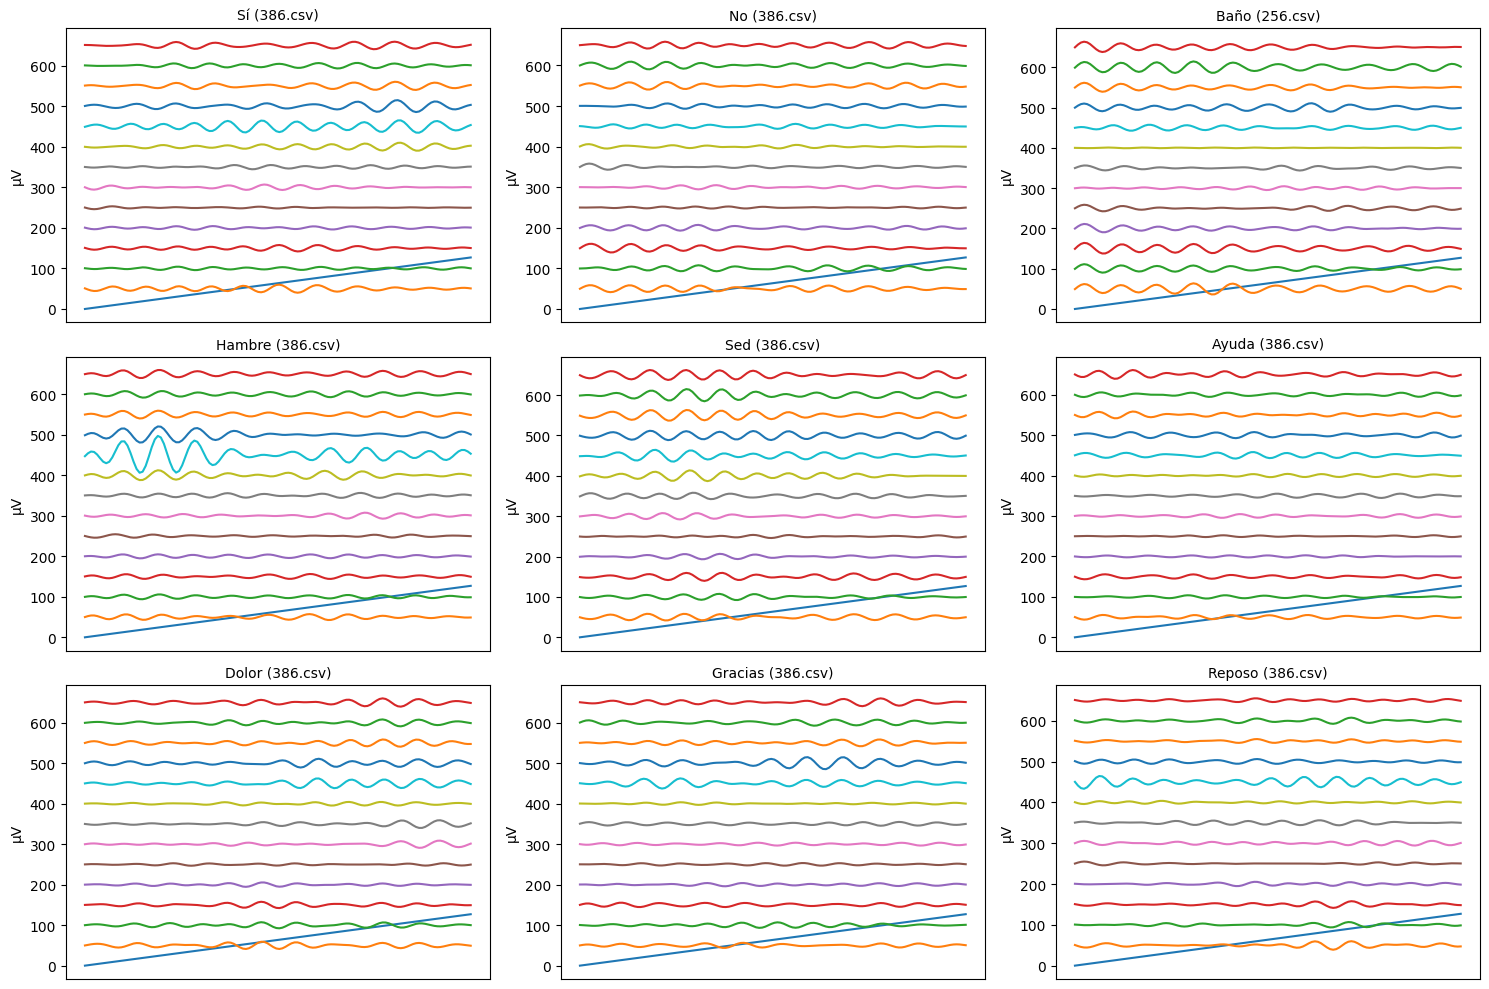

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = "/content/EEGIS - Electroencephalogram Imagined Speech dataset/alpha"

# Mapeamento de classes
CLASS_MAP = {
    "class_0": "Sí",
    "class_1": "No",
    "class_2": "Baño",
    "class_3": "Hambre",
    "class_4": "Sed",
    "class_5": "Ayuda",
    "class_6": "Dolor",
    "class_7": "Gracias",
    "class_8": "Reposo",
}

def load_csv_as_array(path):
    """Carrega CSV de EEG (15x129) e normaliza para (14x128)."""
    df = pd.read_csv(path, header=None)
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=0, how="any")
    df = df.dropna(axis=1, how="any")
    arr = df.values.T
    if arr.shape[0] >= 14 and arr.shape[1] >= 128:
        arr = arr[:14, :128]
    return arr.astype(np.float32)

def sample_per_class():
    """Pega uma amostra (primeiro arquivo válido) de cada classe."""
    samples = []
    for idx, (folder, word) in enumerate(CLASS_MAP.items()):
        folder_path = os.path.join(RAW_DIR, folder)
        if not os.path.isdir(folder_path):
            print(f"[AVISO] Pasta não encontrada: {folder_path}")
            continue
        for fname in os.listdir(folder_path):
            if fname.endswith(".csv"):
                path = os.path.join(folder_path, fname)
                arr = load_csv_as_array(path)
                if arr.shape == (14, 128):
                    samples.append({
                        "classe_id": idx,
                        "classe_nome": word,
                        "arquivo": fname,
                        "amostra": arr.flatten()
                    })
                    break  # só 1 amostra por classe
    return pd.DataFrame(samples)

def plot_grid(df):
    """Plota todas as classes em uma grade 3x3 (cada subplot é uma classe)."""
    n = len(df)
    rows, cols = 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10), sharex=True)

    for ax, (_, row) in zip(axes.flatten(), df.iterrows()):
        arr = row["amostra"].reshape(14, 128)
        for ch in range(arr.shape[0]):
            ax.plot(arr[ch] + ch*50)  # desloca canais
        ax.set_title(f"{row['classe_nome']} ({row['arquivo']})", fontsize=10)
        ax.set_ylabel("µV")
        ax.set_xticks([])

    # Esconde eixos extras (se houver menos que 9 classes)
    for ax in axes.flatten()[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 1. Carregar amostras
    df_samples = sample_per_class()

    # 2. Mostrar DataFrame completo
    pd.set_option("display.max_columns", None)
    pd.set_option("display.max_colwidth", None)
    print("✅ DataFrame com amostras de cada classe:")
    print(df_samples)

    # 3. Plotar grade 3x3
    plot_grid(df_samples)



## 🔹 Fluxo 2: Indexação das amostras no ChromaDB

In [5]:
import chromadb
from chromadb.config import Settings

# Inicializa banco local
client = chromadb.Client(Settings(persist_directory="./chroma_db"))

collection = client.get_or_create_collection("eeg_samples")

# Pegando do seu DataFrame df_samples
for _, row in df_samples.iterrows():
    vector = row["amostra"].tolist()  # numpy → list
    collection.add(
        ids=[f"{row['classe_id']}_{row['arquivo']}"],
        embeddings=[vector],
        metadatas=[{
            "classe_id": int(row["classe_id"]),
            "classe_nome": row["classe_nome"],
            "arquivo": row["arquivo"]
        }]
    )

print("✅ Amostras salvas no banco vetorial!")


✅ Amostras salvas no banco vetorial!


## 🔹 Fluxo 3: Retrieval (RAG + ChromaDB)

In [6]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import chromadb
from chromadb.config import Settings
import google.generativeai as genai
from google.colab import userdata  # se local, use dotenv ou os.environ

# ===========================================
# Configurações iniciais
# ===========================================

CLASS_MAP = {
    0: "Sí",
    1: "No",
    2: "Baño",
    3: "Hambre",
    4: "Sed",
    5: "Ayuda",
    6: "Dolor",
    7: "Gracias",
    8: "Reposo",
}

# Banco vetorial (mesma config que usou ao popular)
client = chromadb.Client(Settings(persist_directory="./chroma_db"))
collection = client.get_or_create_collection("eeg_samples")

# Estado global do histórico
history = []

# ===========================================
# Funções auxiliares
# ===========================================


def infer_sentence_with_gemini(history, candidates, scores=None, idioma="Português", api_key=None, model="gemini-2.5-flash"):
    if api_key is None:
        api_key = userdata.get("GOOGLE_API_KEY")  # ou use dotenv/local var
    if not api_key:
        raise ValueError("❌ GOOGLE_API_KEY não encontrada.")

    genai.configure(api_key=api_key)
    model = genai.GenerativeModel(model)

    historico_texto = [f"{i+1}. {h['frase']}" for i, h in enumerate(history) if 'frase' in h]
    if not historico_texto:
        historico_texto = ["(sem histórico até agora)"]

    if scores:
        candidatos_str = ", ".join([f"{w} (sim={1-d:.2f})" for w, d in zip(candidates, scores)])
    else:
        candidatos_str = ", ".join(candidates)

    prompt = f"""
Você é um assistente que ajuda a decodificar intenções a partir de sinais EEG.

Histórico recente da conversa (em {idioma}):
{os.linesep.join(historico_texto)}

Palavras candidatas sugeridas pelo EEG (com nível de similaridade):
{candidatos_str}

Tarefa:
1. Escolha a palavra mais plausível considerando contexto e similaridade.
2. Construa uma frase coerente e natural no idioma {idioma}, que dê continuidade ao histórico.
3. Se não houver histórico, apenas crie uma frase simples usando a palavra escolhida.
4. Responda **somente em JSON válido**, no seguinte formato:

{{
  "palavra_final": "<palavra escolhida>",
  "frase": "<frase completa no idioma {idioma}>"
}}
"""
    response = model.generate_content(prompt)
    text = response.text.strip()
    if text.startswith("```"):
        text = text.strip("`").replace("json", "").strip()
    try:
        return json.loads(text)
    except Exception:
        return {"palavra_final": text, "frase": ""}



# 💻 Interface Interativa

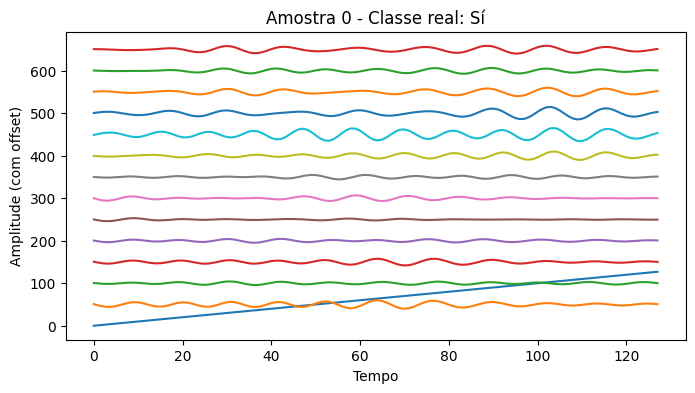


🔎 Resultados da consulta (ChromaDB):
- Sí dist=0.0000 sim=1.0000
- Ayuda dist=28513.3145 sim=-28512.3145
- Reposo dist=49430.9688 sim=-49429.9688

✨ Estou pensando com Gemini...

Palavra final sugerida pelo Gemini: sim
Frase construída: Sim, está correto.

📜 Histórico atualizado:


,palavra_final,frase
0,sim,"Sim, está correto."


In [7]:

# ===========================================
# Funções auxiliares
# ===========================================

def plot_eeg(arr, title):
    """Plota EEG (14x128) com offset entre canais."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for ch in range(arr.shape[0]):
        ax.plot(arr[ch] + ch * 50)
    ax.set_title(title)
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Amplitude (com offset)")
    plt.show()

# ===========================================
# Widgets
# ===========================================

split_dropdown = widgets.Dropdown(options=["train","val","test"], value="test", description="Split:")
idioma_dropdown = widgets.Dropdown(options=["Português","Español","English"], value="Português", description="Idioma:")
topk_slider = widgets.IntSlider(min=1, max=10, value=3, step=1, description="top-k")

# ⚠️ df_samples deve estar carregado (com as amostras por classe)
max_idx = len(df_samples) - 1
slider = widgets.IntSlider(min=0, max=max_idx, step=1, value=0, description="Amostra:")

# Botão de reset histórico
reset_button = widgets.Button(description="Reset Histórico", button_style="danger")

# ===========================================
# Funções de interação
# ===========================================

def on_reset_clicked(b):
    global history
    history = []
    clear_output(wait=True)
    display_ui()
    print("✅ Histórico resetado!")

reset_button.on_click(on_reset_clicked)

# fora de funções (global)
gemini_out = {}

def update_plot(change=None):
    global history, gemini_out  # garante que estamos atualizando o global

    if df_samples.empty:
        clear_output(wait=True)
        display_ui()
        print("⚠️ Nenhuma amostra carregada no DataFrame df_samples.")
        return

    idx = slider.value
    idioma = idioma_dropdown.value
    topk = topk_slider.value

    clear_output(wait=True)
    display_ui()

    # Recupera amostra direto do DataFrame
    vector = df_samples.iloc[idx]["amostra"].tolist()
    meta = {
        "classe_nome": df_samples.iloc[idx]["classe_nome"],
        "classe_id": df_samples.iloc[idx]["classe_id"],
        "arquivo": df_samples.iloc[idx]["arquivo"]
    }

    # Plota EEG
    arr = np.array(vector).reshape(14, 128)
    plot_eeg(arr, f"Amostra {idx} - Classe real: {meta['classe_nome']}")

    # Consulta no banco vetorial
    query_res = collection.query(query_embeddings=[vector], n_results=topk)

    print("\n🔎 Resultados da consulta (ChromaDB):")
    candidates, scores = [], []
    for m, dist in zip(query_res["metadatas"][0], query_res["distances"][0]):
        print(f"- {m['classe_nome']} dist={dist:.4f} sim={1-dist:.4f}")
        candidates.append(m["classe_nome"])
        scores.append(dist)

    # Gemini
    print("\n✨ Estou pensando com Gemini...")
    gemini_out = infer_sentence_with_gemini(history, candidates, scores, idioma=idioma)
    print(f"\nPalavra final sugerida pelo Gemini: {gemini_out['palavra_final']}")
    print(f"Frase construída: {gemini_out['frase']}")

    # Atualiza histórico
    history.append(gemini_out)

    print("\n📜 Histórico atualizado:")
    df_hist = pd.DataFrame(history)
    display(df_hist)

def display_ui():
    display(widgets.HBox([split_dropdown, idioma_dropdown, topk_slider]))
    display(widgets.HBox([slider, reset_button]))

# ===========================================
# Ativação
# ===========================================

slider.observe(update_plot, names="value")
idioma_dropdown.observe(update_plot, names="value")
topk_slider.observe(update_plot, names="value")

display_ui()
update_plot()

# 🌐 Pesquisar na Web

In [10]:
def search_web():
  from google import genai
  from google.genai import types

  client = genai.Client(api_key = userdata.get("GOOGLE_API_KEY"))

  grounding_tool = types.Tool(
      google_search=types.GoogleSearch()
  )

  config = types.GenerateContentConfig(
      tools=[grounding_tool]
  )

  #frase = gemini_out['frase']
  frase = "Qual é o valor do dólar hoje?"
  print("Pesquisando na Web...")

  response = client.models.generate_content(
      model="gemini-2.5-flash",
      contents=frase,
      config=config,
  )

  print(response.text)

search_web()


Pesquisando na Web...
A cotação do dólar comercial hoje, 3 de outubro de 2025, está em aproximadamente R$ 5,34. Alguns portais indicam o valor de R$ 5,3530.

Este valor representa a taxa de câmbio do dólar em relação ao Real Brasileiro, sendo atualizado constantemente para refletir as variações do mercado. A cotação pode variar ligeiramente dependendo da fonte e do momento da consulta.
